# Paper Figures 1–3 — entropic partial OT

Each paper figure has one canonical solve cell and one unique output.
The paper penalty is passed unchanged to `entropic_partial_ot`, whose
real-real cost is `M - 2*lambda`. The JSON sidecars record the extended
marginal residuals and the exact stopping condition for every panel.


In [1]:
import os
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

from pgot import set_reproducible

set_reproducible()
OUTPUT_DIR = Path("outputs")
METADATA_DIR = Path("metadata")
OUTPUT_DIR.mkdir(exist_ok=True)
METADATA_DIR.mkdir(exist_ok=True)


In [2]:
import matplotlib.pyplot as plt

from pgot import (
    FIGURE_PARAMETERS,
    make_figure1,
    make_figure2,
    make_figure3,
    paper_gaussian_mixtures,
    solve_epot_panels,
    write_figure_sidecar,
)

source, target = paper_gaussian_mixtures()
gmm_inputs = {
    "source": {
        "weights": source.weights,
        "means": source.comp_mean,
        "covariances": source.comp_cov,
    },
    "target": {
        "weights": target.weights,
        "means": target.comp_mean,
        "covariances": target.comp_cov,
    },
    "cost": "squared Gaussian W2 divided by its cross-matrix maximum",
}


## Figure 1

Continuous coupling-weight colormap with a horizontal colorbar. Component
labels, pair categories, and the pair legend are intentionally absent.


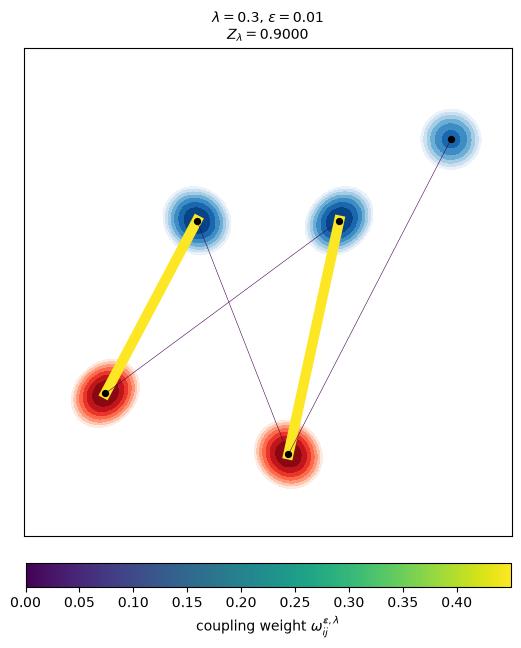

In [3]:
figure1_records = solve_epot_panels([0.3], [0.01], source, target)
figure1 = make_figure1(figure1_records)
figure1_path = OUTPUT_DIR / "figure1.pdf"
figure1.savefig(figure1_path, format="pdf", bbox_inches="tight")
write_figure_sidecar(
    METADATA_DIR / "figure1.json",
    figure=1,
    outputs=[figure1_path],
    panels=figure1_records,
    inputs=gmm_inputs,
    seeds={"sampling": None, "fit": None},
    notes="Known GMMs; no sampling or fitting.",
)
plt.show()


## Figure 2

The exact paper sweep: one row and five lambda values at epsilon=0.01.


[(0.0, 1.46e-05), (0.125, 0.4196413), (0.25, 0.8999999), (0.375, 0.9488552), (0.5, 0.9999755)]


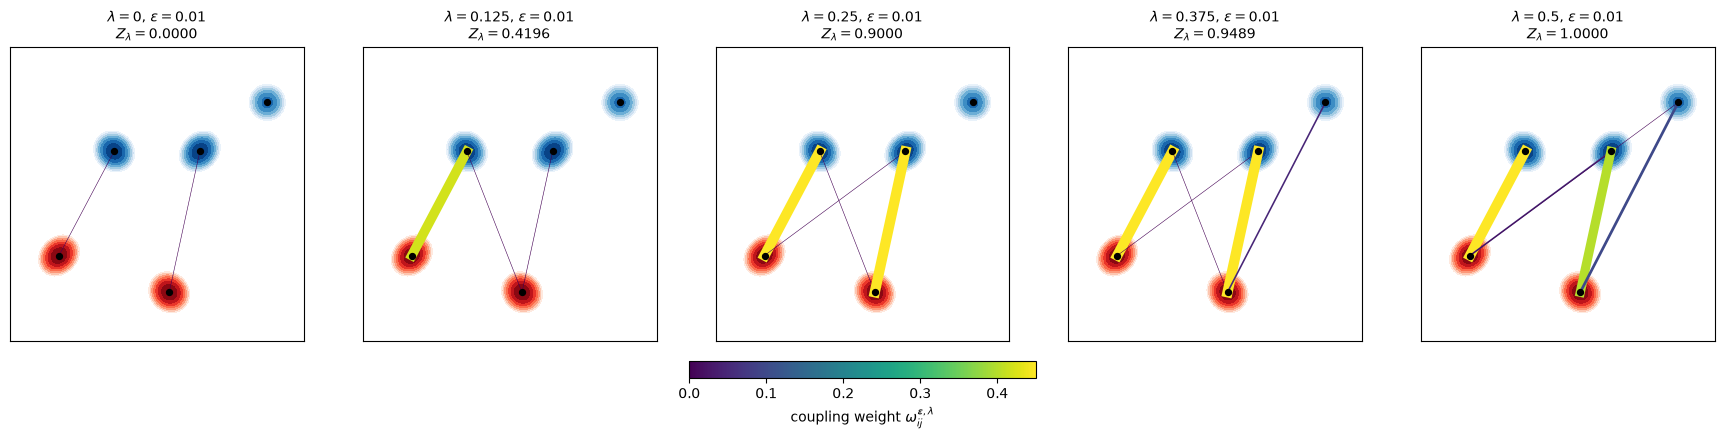

In [4]:
params2 = FIGURE_PARAMETERS[2]
figure2_records = solve_epot_panels(
    params2["lambda"], [params2["epsilon"]], source, target
)
figure2 = make_figure2(figure2_records)
figure2_path = OUTPUT_DIR / "figure2.pdf"
figure2.savefig(figure2_path, format="pdf", bbox_inches="tight")
write_figure_sidecar(
    METADATA_DIR / "figure2.json",
    figure=2,
    outputs=[figure2_path],
    panels=figure2_records,
    inputs=gmm_inputs,
    seeds={"sampling": None, "fit": None},
    notes="Exact 1 x 5 paper sweep.",
)
print([(r["paper_lambda"], round(r["matched_mass"], 7)) for r in figure2_records])
plt.show()


## Figure 3

Seven lambda columns and three epsilon rows. The color scale is the maximum
coupling weight across these 21 solves—not the unrelated cost maximum.
A stalled Sinkhorn panel is refined on the same convex entropic objective,
and the sidecar records both the fallback and final marginal residuals.


lambda=0.1250, epsilon=0.01, mass=0.4196413, solver=POT sinkhorn, residual=1.38e-11
lambda=0.1875, epsilon=0.01, mass=0.8892349, solver=POT sinkhorn, residual=5.73e-11
lambda=0.2500, epsilon=0.01, mass=0.8999999, solver=POT sinkhorn, residual=2.37e-11
lambda=0.3125, epsilon=0.01, mass=0.9000163, solver=POT sinkhorn, residual=2.96e-11
lambda=0.3750, epsilon=0.01, mass=0.9488552, solver=POT sinkhorn, residual=5.18e-11
lambda=0.4375, epsilon=0.01, mass=0.9894975, solver=POT sinkhorn, residual=8.16e-11
lambda=0.5000, epsilon=0.01, mass=0.9999755, solver=POT sinkhorn + SciPy SLSQP refinement, residual=5.55e-17
lambda=0.1250, epsilon=0.11, mass=0.4127988, solver=POT sinkhorn, residual=6.15e-12
lambda=0.1875, epsilon=0.11, mass=0.5432604, solver=POT sinkhorn, residual=5.55e-17
lambda=0.2500, epsilon=0.11, mass=0.6641090, solver=POT sinkhorn, residual=7.15e-14
lambda=0.3125, epsilon=0.11, mass=0.7620644, solver=POT sinkhorn, residual=1.45e-13
lambda=0.3750, epsilon=0.11, mass=0.8339415, solver

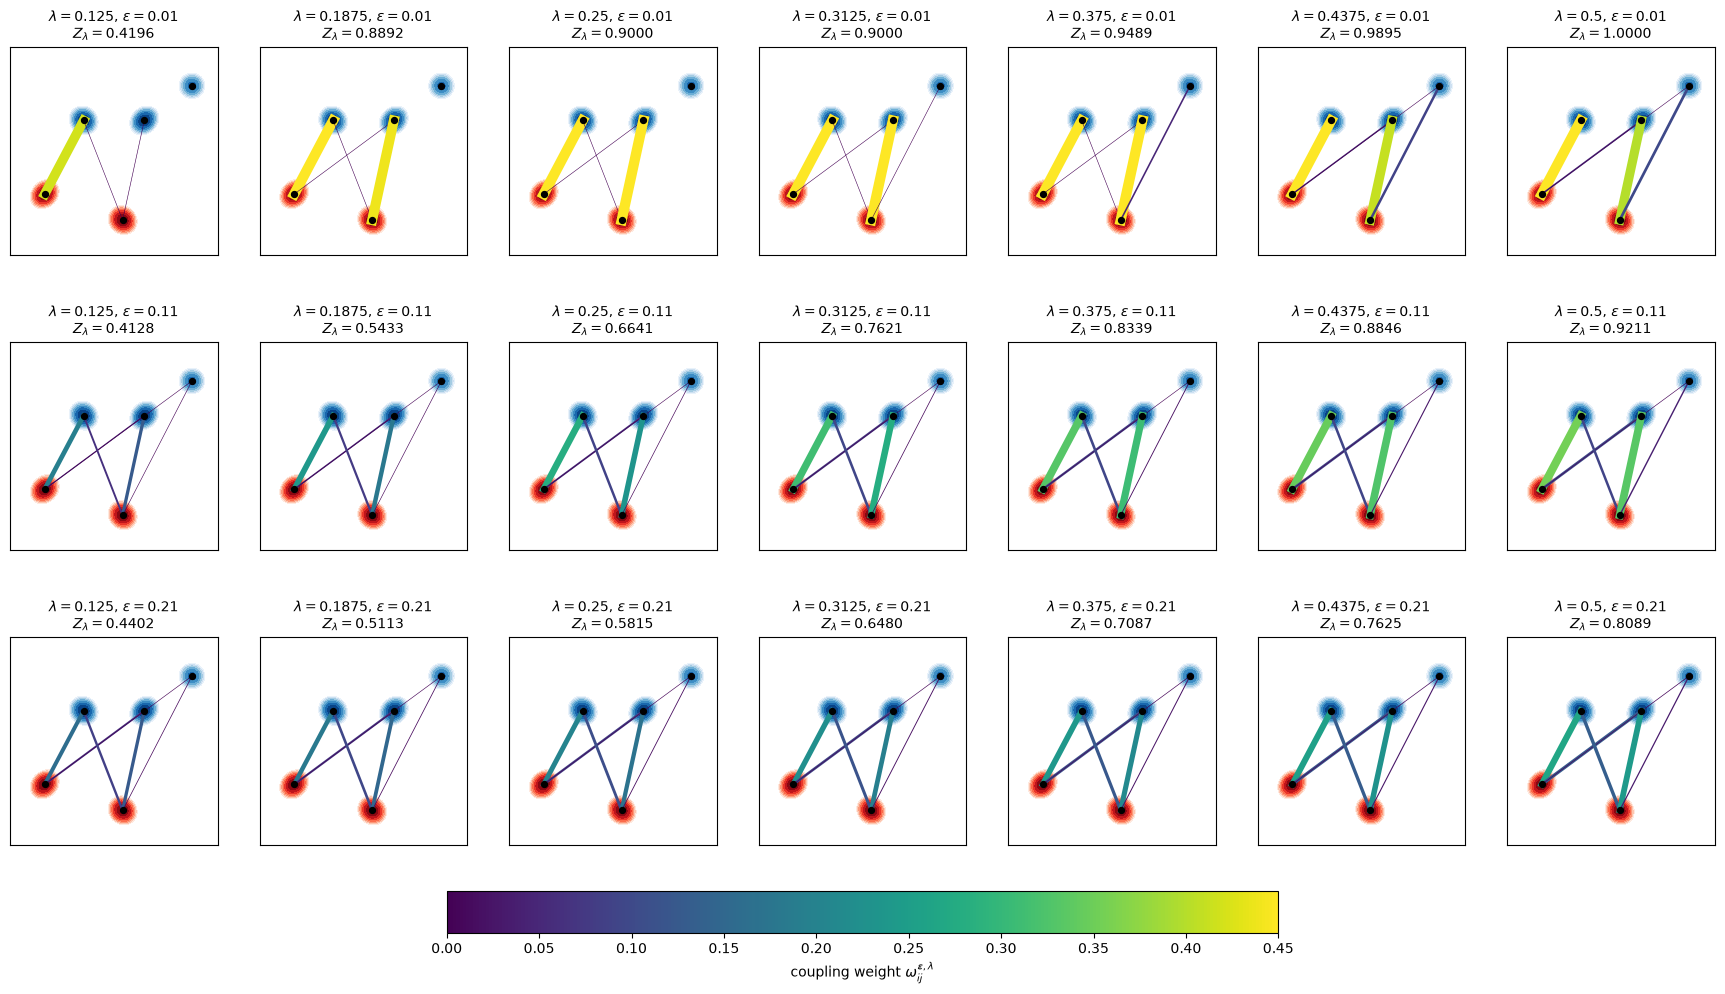

In [5]:
params3 = FIGURE_PARAMETERS[3]
figure3_records = solve_epot_panels(
    params3["lambda"], params3["epsilon"], source, target
)
figure3 = make_figure3(figure3_records)
figure3_path = OUTPUT_DIR / "figure3.pdf"
figure3.savefig(figure3_path, format="pdf", bbox_inches="tight")
write_figure_sidecar(
    METADATA_DIR / "figure3.json",
    figure=3,
    outputs=[figure3_path],
    panels=figure3_records,
    inputs=gmm_inputs,
    seeds={"sampling": None, "fit": None},
    notes="3 x 7 paper sweep; shared coupling-weight color scale.",
)
for record in figure3_records:
    print(
        f"lambda={record['paper_lambda']:.4f}, epsilon={record['epsilon']:.2f}, "
        f"mass={record['matched_mass']:.7f}, solver={record['solver']}, "
        f"residual={max(record['row_residual'], record['column_residual']):.2e}"
    )
plt.show()
